In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
train = pd.read_csv("ka3_dataset/train.csv")
test = pd.read_csv("ka3_dataset/test.csv")
sample_submission = pd.read_csv("ka3_dataset/sample_submission.csv")

train["is_train"] = 1
test["is_train"] = 0

In [ ]:
df = pd.concat([train, test], axis=0)
df.head()

In [ ]:
df.shape, train.shape, test.shape

### Let's perfrom eda and fe

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
# i want to view entire phrase
pd.set_option("display.max_colwidth", None)

df["phrase"].head(5)

### Handling Phrase feature

In [ ]:
df["phrase"]

In [ ]:
import re
def cleanText(text):
    text = re.sub(r"`", "", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\.{2,}", " ", text)
    text = text.replace('"', "") 
    return " ".join(text.split())

In [ ]:
df["phrase"]= df["phrase"].fillna("")
df["phrase"] = df["phrase"].apply(lambda x: cleanText(x))

In [ ]:
df["char_len"] = df["phrase"].str.len()
df["word_len"] = df["phrase"].str.split().str.len()

In [ ]:
df["num_!"] = df["phrase"].str.count("!")
df["num_?"] = df["phrase"].str.count(r"\?")

In [ ]:
df.head()
# df.groupby("sentiment")[["char_len", "word_len"]].value_counts()

### Handling missing values

In [ ]:
df.isna().sum()

In [ ]:
df.nunique()

In [ ]:
df.columns

In [ ]:
num_cols = ["feature_1", "feature_2", "feature_3"]
df[num_cols]

In [ ]:
train_df = df[df["is_train"]==1]
test_df = df[df["is_train"]==0]

train_df = train_df.drop(["is_train"], axis = 1)
test_df = test_df.drop(["is_train"], axis = 1) 

train_df.shape, train.shape, test_df.shape, test.shape, 

### Visuals

In [ ]:
sns.boxplot(data = df.dropna(), x = "sentiment", y = "feature_1")

### Checking for outliers

In [ ]:
for i in ["feature_1", "feature_2", "feature_3"]:
    plt.title(f"Boxlpot for {i}")
    plt.xlabel = i
    sns.boxplot(data = df.dropna(), x = "sentiment", y = i)
    plt.show()

In [ ]:
nums = ['char_len', 'word_len', 'num_!', 'num_?']
for i in nums:
    plt.title(f"Boxlpot for {i}")
    plt.xlabel = i
    plt.boxplot(df[i])
    plt.show()

In [ ]:
nums = ['num_!', 'num_?']
for i in nums+["sentiment"]:
    plt.title(f"Counterplot for {i}")
    plt.xlabel = i
    sns.countplot(data = df, x = i)
    plt.show()

In [ ]:
for i in ["word_len", "char_len"]:
    plt.title(f"Distribution plot for {i}")
    plt.xlabel = i
    sns.histplot(data = df, x = i, kde = True)
    plt.show()  

In [ ]:
for i in ["word_len", "char_len"]:
    plt.title(f"Distribution plot for {i}")
    plt.xlabel = i
    sns.histplot(data = df, x = "sentiment", y = i)
    plt.show()

In [ ]:
numcols = ["feature_1", "feature_2", "feature_3", 'char_len', 'word_len', 'num_!', 'num_?']
coef = df[numcols].corr()
sns.heatmap(coef, annot = True, cmap = "coolwarm")

In [305]:
from sklearn.model_selection import train_test_split
X = train_df.drop(["sentiment", "word_len"], axis = 1)
y = train_df["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify= y
) 

### Feature selection and feature importance

In [306]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif

for i in [chi2, f_classif, mutual_info_classif]:
    print(i.__name__)
    skb = SelectKBest(k = 5, score_func=i)
    skb.fit(df.dropna()[numcols], df.dropna()["sentiment"])
    print(skb.get_feature_names_out())

chi2
['feature_1' 'feature_2' 'char_len' 'word_len' 'num_?']
f_classif
['feature_1' 'feature_2' 'char_len' 'word_len' 'num_?']
mutual_info_classif
['feature_1' 'feature_2' 'feature_3' 'char_len' 'word_len']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion #used for two or more text vectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["feature_1", "feature_2", "feature_3", "char_len","num_!", "num_?"]

numerical_cols = Pipeline([
    ("impute",SimpleImputer(strategy='median', add_indicator=True)),
    ("scale", StandardScaler(with_mean=False)) # with_mean=False because of sparse matrix from tfidf vectorizer
])

tfidf_pipe = FeatureUnion([
    ("word",TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=30000)),
    ("char", TfidfVectorizer(ngram_range=(3,4), min_df=1, max_features=30000, analyzer="char"))
])

process = ColumnTransformer(transformers=[
    ("nums", numerical_cols, num_cols),
    ("text", tfidf_pipe, "phrase")
])



In [308]:
X_train_final = process.fit_transform(X_train)
X_val_final = process.transform(X_val)
test_final = process.transform(test_df)

In [309]:
X_train_final.shape, X_val_final.shape, test_final.shape 

((5600, 60009), (1400, 60009), (1700, 60009))

### Model training and evaluation

In [310]:
from sklearn.linear_model import RidgeClassifier, SGDClassifier, LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

In [ ]:
model = {
    "LogisticReg": LogisticRegression(max_iter=1000),
    "RidgeClassifier": RidgeClassifier(),
    "SGDClassifier": SGDClassifier(loss= "log_loss"),
    "LinearSVC": LinearSVC(max_iter=3000),
    "DecisionTreeClassifier": DecisionTreeClassifier()
    # "AdaBoostClassifier": AdaBoostClassifier()
    # "GradientBoostingClassifier": GradientBoostingClassifier(),
    # "RandomForestClassifier": RandomForestClassifier()
}

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

for name, model in model.items():
    model.fit(X_train_final, y_train)
    y_preds = model.predict(X_val_final)
    print(f"{name} accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")
    print()


### Baseline models
```markdown
LogisticReg accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.66      0.71      0.68       537
         1.0       0.37      0.13      0.19       269
         2.0       0.68      0.84      0.75       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.54      1400
weighted avg       0.61      0.65      0.62      1400


RidgeClassifier accurace is : 0.6479 
               precision    recall  f1-score   support

         0.0       0.66      0.69      0.68       537
         1.0       0.34      0.16      0.22       269
         2.0       0.69      0.82      0.75       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.55      1400
weighted avg       0.61      0.65      0.62      1400


SGDClassifier accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.64      0.75      0.69       537
         1.0       0.45      0.11      0.17       269
         2.0       0.68      0.81      0.74       594

    accuracy                           0.65      1400
   macro avg       0.59      0.56      0.53      1400
weighted avg       0.62      0.65      0.61      1400


LinearSVC accurace is : 0.6336 
               precision    recall  f1-score   support

         0.0       0.65      0.67      0.66       537
         1.0       0.32      0.19      0.23       269
         2.0       0.69      0.80      0.74       594

    accuracy                           0.63      1400
   macro avg       0.55      0.55      0.55      1400
weighted avg       0.60      0.63      0.61      1400


DecisionTreeClassifier accurace is : 0.4536 
               precision    recall  f1-score   support

         0.0       0.47      0.45      0.46       537
         1.0       0.22      0.23      0.23       269
         2.0       0.55      0.56      0.55       594

    accuracy                           0.45      1400
   macro avg       0.41      0.41      0.41      1400
weighted avg       0.46      0.45      0.46      1400


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
AdaBoostClassifier accurace is : 0.5107 
               precision    recall  f1-score   support

         0.0       0.48      0.58      0.53       537
         1.0       0.00      0.00      0.00       269
         2.0       0.54      0.68      0.60       594

    accuracy                           0.51      1400
   macro avg       0.34      0.42      0.38      1400
weighted avg       0.41      0.51      0.46      1400


GradientBoostingClassifier accurace is : 0.5786 
               precision    recall  f1-score   support

         0.0       0.59      0.59      0.59       537
         1.0       0.27      0.05      0.08       269
         2.0       0.59      0.81      0.68       594

    accuracy                           0.58      1400
   macro avg       0.48      0.48      0.45      1400
weighted avg       0.53      0.58      0.53      1400


RandomForestClassifier accurace is : 0.6093 
               precision    recall  f1-score   support

         0.0       0.60      0.68      0.63       537
         1.0       0.65      0.04      0.08       269
         2.0       0.62      0.81      0.70       594

    accuracy                           0.61      1400
   macro avg       0.62      0.51      0.47      1400
weighted avg       0.62      0.61      0.55      1400```

### HPT

In [ ]:
# hyperparameter tuning - lr
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000)
param_grid = {
    "C": [0.5, 0.75, 1, 1.25, 1.5, 2],
    "class_weight": [None],
    "solver": ["lbfgs", "saga"]
}
random_lr = RandomizedSearchCV(estimator=lr, param_distributions=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_lr.fit(X_train_final, y_train)
print(f"Best parameters: {random_lr.best_params_}")
best_lr = random_lr.best_estimator_
y_preds = best_lr.predict(X_val_final)
print(f"LogisticReg accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

```markdown
Best parameters: {'solver': 'liblinear', 'class_weight': None, 'C': 1}
LogisticReg accurace is : 0.6550 
               precision    recall  f1-score   support

         0.0       0.66      0.72      0.69       537
         1.0       0.42      0.08      0.14       269
         2.0       0.67      0.86      0.75       594

    accuracy                           0.66      1400
   macro avg       0.58      0.55      0.53      1400
weighted avg       0.62      0.66      0.61      1400
-------
Best parameters: {'solver': 'lbfgs', 'class_weight': None, 'C': 1}
LogisticReg accurace is : 0.6550 
               precision    recall  f1-score   support

         0.0       0.66      0.72      0.69       537
         1.0       0.40      0.13      0.19       269
         2.0       0.68      0.84      0.75       594

    accuracy                           0.66      1400
   macro avg       0.58      0.56      0.54      1400
weighted avg       0.62      0.66      0.62      1400
```

In [316]:
# we learnt that balanced weights were not best for accuracy.. - valid for all models(verified)

lsvc = LinearSVC()
param_grid = {
    "C": [0.3],#[0.1, 0.3, 1, 3, 10],
    "class_weight": [None],
    "max_iter": [1000]#[1000, 3000, 5000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_ = RandomizedSearchCV(estimator=lsvc, param_distributions=param_grid, cv =cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_.fit(X_train_final, y_train)
print(f"Best parameters: {random_.best_params_}")
best_lsvc = random_.best_estimator_
y_preds = best_lsvc.predict(X_val_final)
print(f"LinearSVC accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ............C=0.3, class_weight=None, max_iter=1000; total time=  12.8s


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ............C=0.3, class_weight=None, max_iter=1000; total time=  14.8s


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ............C=0.3, class_weight=None, max_iter=1000; total time=  15.7s
[CV] END ............C=0.3, class_weight=None, max_iter=1000; total time=  15.8s


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ............C=0.3, class_weight=None, max_iter=1000; total time=  16.5s
Best parameters: {'max_iter': 1000, 'class_weight': None, 'C': 0.3}
LinearSVC accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.66      0.70      0.68       537
         1.0       0.37      0.15      0.22       269
         2.0       0.69      0.84      0.76       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.55      1400
weighted avg       0.62      0.65      0.62      1400



/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


```markdown
Best parameters: {'max_iter': 1000, 'class_weight': None, 'C': 0.3}
LinearSVC accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.66      0.70      0.68       537
         1.0       0.37      0.15      0.22       269
         2.0       0.69      0.84      0.76       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.55      1400
weighted avg       0.62      0.65      0.62      1400
```

In [ ]:
sgd = SGDClassifier()
param_grid = {
    "loss": ["hinge", "log_loss"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
    "class_weight": [None, "balanced"],
    "max_iter": [1000, 3000, 5000]
}           
random_sgd = RandomizedSearchCV(estimator=sgd, param_distributions=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_sgd.fit(X_train_final, y_train)
print(f"Best parameters: {random_sgd.best_params_}")
best_sgd = random_sgd.best_estimator_
y_preds = best_sgd.predict(X_val_final)
print(f"SGDClassifier accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

```markdown
Best parameters: {'max_iter': 3000, 'loss': 'hinge', 'class_weight': None, 'alpha': 0.0001}
SGDClassifier accurace is : 0.6229 
               precision    recall  f1-score   support

         0.0       0.67      0.62      0.65       537
         1.0       0.32      0.22      0.26       269
         2.0       0.67      0.80      0.73       594

    accuracy                           0.62      1400
   macro avg       0.55      0.55      0.55      1400
weighted avg       0.60      0.62      0.61      1400
```

## Comparision of models

LogisticRegression accurace is : 0.6550 
               precision    recall  f1-score   support

         0.0       0.66      0.72      0.69       537
         1.0       0.40      0.13      0.19       269
         2.0       0.68      0.84      0.75       594

    accuracy                           0.66      1400
   macro avg       0.58      0.56      0.54      1400
weighted avg       0.62      0.66      0.62      1400


LinearSVC accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.66      0.70      0.68       537
         1.0       0.37      0.15      0.22       269
         2.0       0.69      0.84      0.76       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.55      1400
weighted avg       0.62      0.65      0.62      1400


SGDClassifier accurace is : 0.6157 
               precision    recall  f1-score   support

         0.0       0.70      0.54      0.61       537
         1.0   

<Axes: >

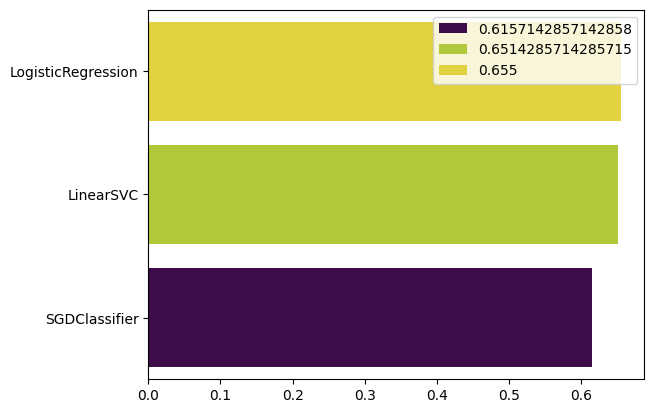

In [320]:
# all hpt comparisions results
models = {
    "LogisticRegression": best_lr,
    "LinearSVC": best_lsvc,
    "SGDClassifier": best_sgd,
}
res = {}
for name, model in models.items():
    y_preds = model.predict(X_val_final)
    res[name] = accuracy_score(y_val, y_preds)
    print(f"{name} accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")
    print()

# plot
sns.barplot(y = list(res.keys()), x = list(res.values()),hue = list(res.values()), palette = "viridis")

## Ensembling

In [303]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("svc", best_lsvc)
    ],
    voting="hard"
)
ensemble.fit(X_train_final, y_train)
y_preds = ensemble.predict(X_val_final)
print(f"Ensemble accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Ensemble accurace is : 0.6543 
               precision    recall  f1-score   support

         0.0       0.65      0.73      0.69       537
         1.0       0.38      0.15      0.22       269
         2.0       0.70      0.82      0.75       594

    accuracy                           0.65      1400
   macro avg       0.58      0.57      0.55      1400
weighted avg       0.62      0.65      0.62      1400



/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Submission 

In [ ]:
y_preds_test = ensemble.predict(test_final)
submission = sample_submission.copy(deep=True)
submission["sentiment"] = y_preds_test
submission.to_csv("submission.csv", index=False)

,id,sentiment
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
1695,1695,0
1696,1696,0
1697,1697,0
1698,1698,0
